# 04. H1-Aggregation Experiment --- Operationalising the Cumulation Hypothesis

The cumulation hypothesis from \§4.14 of the EDA states that the target at horizon $k \in \{3, 10, 25\}$ is approximately the rolling sum of the H=1 target over the next $k$ steps:

$$y^{H_k}_t \;\approx\; \sum_{i=0}^{k-1} y^{H_1}_{t+i}.$$

We verified this empirically: across 500 stratified triples the median Pearson correlation between $y^{H_k}_t$ and the rolling sum of $y^{H_1}$ over $k$ steps is 0.96, 0.94 and 0.91 at $k = 3, 10, 25$ respectively.

This notebook **tests whether the cumulation property is exploitable as a modelling strategy.** We compare two approaches:

- **Per-horizon strategy (notebook 03 baseline).** Train four independent LightGBM models, one per horizon. Each model is trained, tuned, and evaluated on its own horizon's rows.
- **H1-aggregation strategy (this notebook).** Train one LightGBM on H=1 rows only. Derive predictions for H3, H10, H25 by summing the H1 model's predictions over the appropriate windows.

The two approaches are scored on the same canonical chronological holdout, restricted to rows where the full H1 prediction window is available. Bootstrap 95\% confidence intervals are reported for every skill score so the comparison is statistically calibrated.

**Why this is a real test, not a foregone conclusion.** Two competing forces drive the outcome:

- *Reasons the H1-aggregation approach might win:* the H1 model has strictly more training rows than any per-horizon model, the cumulation structure is enforced by construction (predicted H3 always equals the sum of three predicted H1s), and the deployed model is simpler.
- *Reasons it might lose:* errors compound across the rolling sum --- a small per-step noise of $\varepsilon$ becomes roughly $\sqrt{k}\varepsilon$ at horizon $k$, so a direct H25 fit can in principle have lower variance because it predicts the cumulative sum directly without compounding.

Either result is publishable: a win validates the cumulation argument empirically, a loss shows that error compounding outweighs the structural advantage.


## 0. Setup

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from cf import io, viz, splits, metrics, features

viz.apply_report_style()

SEED = 0
np.random.seed(SEED)

SERIES_KEYS = ['code', 'sub_code', 'sub_category', 'horizon']
TRIPLE_KEYS = ['code', 'sub_code', 'sub_category']
FIG_DIR = io.FIGURES_DIR

LAGS = (1, 2, 3, 5, 10)
WINDOWS = (5, 10, 25)
HORIZONS = [1, 3, 10, 25]
N_OPTUNA_TRIALS = 20
N_BOOT = 500
TUNING_SUBSAMPLE = 200_000
print('Setup ok.')


Setup ok.


## 1. Load the panel and engineer features

This block mirrors notebook 03 exactly: same lazy polars feature engineering, same drop of NaN-lag rows, same canonical chronological split assignment. We make sure the same feature set is used so the H1-aggregation result is directly comparable to notebook 03's per-horizon LightGBM.


In [2]:
lf = pl.scan_parquet(io.RAW_DIR / 'train.parquet')
lf = features.add_lag_features(lf, lags=LAGS)
lf = features.add_rolling_features(lf, windows=WINDOWS)
df = lf.collect()
print(f'Engineered panel: {df.shape}')
panel = df.to_pandas()
del df

for col in ['code', 'sub_code', 'sub_category']:
    panel[f'{col}_idx'] = pd.factorize(panel[col])[0]

panel['split'] = panel['ts_index'].apply(splits.assign_split)
lag_cols = [f'lag_{k}' for k in LAGS]
roll_cols = [f'roll_mean_{w}' for w in WINDOWS] + [f'roll_std_{w}' for w in WINDOWS]
panel = panel.dropna(subset=lag_cols).reset_index(drop=True)

feature_cols_raw = [c for c in panel.columns if c.startswith('feature_')]
cat_cols = ['code_idx', 'sub_code_idx', 'sub_category_idx']
FEATURES = feature_cols_raw + lag_cols + roll_cols + cat_cols
print(f'feature count: {len(FEATURES)}')
print('Split row counts:')
print(panel['split'].value_counts())

Engineered panel: (5337414, 105)


feature count: 100
Split row counts:
split
train      3836786
meta        567955
holdout     565473
Name: count, dtype: int64


## 2. Prepare H1-only training data

The H1 model is trained on H=1 rows only. The Optuna tuning subsample, the inner-validation tail, and the eventual scoring are all H=1-row-restricted at this stage. Aggregation to H3/H10/H25 happens only at evaluation time, *after* the H1 model has been fit and used to predict.


In [3]:
h1 = panel[panel['horizon'] == 1].copy()
h1_train = h1[(h1['split'] == 'train') & (h1['ts_index'] <= 2700)]
h1_inner_val = h1[(h1['split'] == 'train') & (h1['ts_index'] > 2700)]

print(f'H1 train (ts <= 2700)        : {len(h1_train):,}')
print(f'H1 inner-val (2700 < ts <= 2880): {len(h1_inner_val):,}')
print(f'Total H1 train pool          : {len(h1[h1["split"] == "train"]):,}')

H1 train (ts <= 2700)        : 929,280
H1 inner-val (2700 < ts <= 2880): 75,119
Total H1 train pool          : 1,004,399


## 3. Hyperparameter tuning via Optuna

Same protocol as notebook 03: 20 trials on a 200{,}000-row subsample, evaluating each candidate on the inner-validation tail with weighted skill score. The H1 model's tuned hyperparameters are then refit on the full H1 training set in the next section.


In [4]:
def make_lgbm(params):
    return lgb.LGBMRegressor(
        objective='regression',
        n_estimators=2000,
        verbosity=-1,
        n_jobs=-1,
        random_state=SEED,
        **params,
    )


rng = np.random.default_rng(SEED)
sub = rng.choice(len(h1_train), size=min(TUNING_SUBSAMPLE, len(h1_train)), replace=False)
Xtr_sub = h1_train.iloc[sub][FEATURES]
ytr_sub = h1_train.iloc[sub]['y_target'].astype(np.float64).values
wtr_sub = h1_train.iloc[sub]['weight'].astype(np.float64).values
Xva = h1_inner_val[FEATURES]
yva = h1_inner_val['y_target'].astype(np.float64).values
wva = h1_inner_val['weight'].astype(np.float64).values


def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 16, 128),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 1000),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': 1,
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
    }
    model = make_lgbm(params)
    model.fit(Xtr_sub, ytr_sub, sample_weight=wtr_sub,
              eval_set=[(Xva, yva)], eval_sample_weight=[wva],
              categorical_feature=cat_cols,
              callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
    pred = model.predict(Xva)
    return -metrics.weighted_skill_score(yva, pred, wva)

study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

best_params = study.best_params
inner_skill = -study.best_value
print(f'Best inner-val skill: {inner_skill:.4f}')
print(f'Best params: {best_params}')

Best inner-val skill: 0.0344
Best params: {'num_leaves': 111, 'learning_rate': 0.010131851327344458, 'min_data_in_leaf': 803, 'feature_fraction': 0.7865948246485545, 'bagging_fraction': 0.9166702460118668, 'lambda_l1': 9.591321307007467, 'lambda_l2': 1.9723526877226611}


## 4. Final fit on the full H1 training panel

Refit the tuned H1 model on the entire H1 training slice (`ts_index <= 2880`), with early stopping on the inner-validation tail to avoid overfitting.


In [5]:
Xtr = h1[h1['split'] == 'train'][FEATURES]
ytr = h1[h1['split'] == 'train']['y_target'].astype(np.float64).values
wtr = h1[h1['split'] == 'train']['weight'].astype(np.float64).values

# Inner-val for early stopping (chronological tail of train)
Xva_full = h1_inner_val[FEATURES]
yva_full = h1_inner_val['y_target'].astype(np.float64).values
wva_full = h1_inner_val['weight'].astype(np.float64).values

h1_model = make_lgbm(best_params)
h1_model.fit(Xtr, ytr, sample_weight=wtr,
             eval_set=[(Xva_full, yva_full)], eval_sample_weight=[wva_full],
             categorical_feature=cat_cols,
             callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)])
print(f'best_iteration: {h1_model.best_iteration_}')

best_iteration: 2000


## 5. Predict H1 on every H1 row in the panel

We need H1 predictions on every H1 row from `ts_index = 11` (the first row with full lag features) through 3601 to support aggregation later. The model was trained only on rows with `ts_index <= 2880`, so predictions on the meta and holdout slices are out-of-sample.


In [6]:
h1_full = h1.copy()
h1_full['pred_h1'] = h1_model.predict(h1_full[FEATURES])
h1_full = h1_full[TRIPLE_KEYS + ['ts_index', 'split', 'pred_h1', 'y_target', 'weight']].rename(
    columns={'y_target': 'y_h1', 'weight': 'w_h1'}
)
h1_full = h1_full.sort_values(TRIPLE_KEYS + ['ts_index']).reset_index(drop=True)
print(f'H1 predictions saved: {len(h1_full):,} rows')
h1_full.head()

H1 predictions saved: 1,302,527 rows


,code,sub_code,sub_category,ts_index,split,pred_h1,y_h1,w_h1
0,10BAVIDU,236HB58W,DPPUO5X2,3543,holdout,-0.104590,-1.473113,0.036910
1,10BAVIDU,236HB58W,DPPUO5X2,3544,holdout,-0.347742,0.498433,0.036580
2,10BAVIDU,236HB58W,DPPUO5X2,3545,holdout,-0.275154,2.053416,0.038369
3,10BAVIDU,236HB58W,DPPUO5X2,3546,holdout,-0.276952,-2.273399,0.038640
4,10BAVIDU,236HB58W,DPPUO5X2,3547,holdout,-0.375376,-1.709834,0.038684


## 6. Aggregate H1 predictions to derive H3, H10, H25

For each H1 row at $(A, B, C, t)$, we compute the rolling sum of the next $k$ H1 predictions for the same triple. The aggregated prediction for H$k$ at time $t$ is therefore $\sum_{i=0}^{k-1} \hat y^{H_1}_{t+i}$, exactly mirroring the cumulation property the model is supposed to exploit.

A row at time $t$ produces a valid H$k$-aggregated prediction only if H1 predictions exist at $t, t+1, \ldots, t+k-1$ for the same triple. Rows that fall off the end of a triple's available H1 history produce NaN in the aggregated prediction column.


In [7]:
def add_rolling_sum(df, k, group_keys=TRIPLE_KEYS, ts_col='ts_index', val_col='pred_h1'):
    """Forward rolling sum of length k, computed per group, indexed by ts_index.

    For row t, the aggregated H_k prediction is sum of pred_h1 at t, t+1, ..., t+k-1.
    Implemented as a backward rolling sum on the time-reversed series, then realigned.
    Sets NaN where the full window is unavailable.
    """
    out = df.copy()
    # Sort each group ascending by ts_index
    out = out.sort_values(group_keys + [ts_col]).reset_index(drop=True)
    # Reverse within each group, take rolling sum of length k, reverse again
    grouped = out.groupby(group_keys, sort=False)[val_col]
    forward_sum = grouped.transform(
        lambda s: s.iloc[::-1].rolling(window=k, min_periods=k).sum().iloc[::-1]
    )
    out[f'pred_agg_h{k}'] = forward_sum
    return out


h1_full = add_rolling_sum(h1_full, 3)
h1_full = add_rolling_sum(h1_full, 10)
h1_full = add_rolling_sum(h1_full, 25)
print('Aggregated columns added.')
print('Non-null counts:')
for k in (3, 10, 25):
    nn = h1_full[f'pred_agg_h{k}'].notna().sum()
    print(f'  H{k}: {nn:,} rows have a valid aggregated prediction')

Aggregated columns added.
Non-null counts:
  H3: 1,284,227 rows have a valid aggregated prediction
  H10: 1,220,511 rows have a valid aggregated prediction
  H25: 1,086,229 rows have a valid aggregated prediction


## 7. Score aggregated predictions on the canonical holdout

For each $H_k \in \{3, 10, 25\}$, we restrict the holdout to rows where the H1-aggregation produced a valid prediction (i.e., the full H1 prediction window was available), then score the aggregated prediction against the actual H$k$ target. The same restricted slice is used to re-score notebook 03's per-horizon LightGBM, so the comparison is on identical rows.


In [8]:
# Load notebook 03's per-horizon predictions on the canonical holdout
lgbm_holdout = io.load_processed('lgbm_predictions_holdout')
print(f'notebook 03 holdout predictions: {len(lgbm_holdout):,}')

# Build a panel of H3, H10, H25 holdout rows with truth/weight + per-horizon prediction
def build_horizon_holdout(h):
    rows = panel[(panel['horizon'] == h) & (panel['split'] == 'holdout')].copy()
    rows = rows[TRIPLE_KEYS + ['ts_index', 'y_target', 'weight']].rename(
        columns={'y_target': f'y_h{h}', 'weight': f'w_h{h}'}
    )
    # join per-horizon LGBM predictions
    pred = lgbm_holdout[lgbm_holdout['horizon'] == h][TRIPLE_KEYS + ['ts_index', 'pred_lgbm']]
    rows = rows.merge(pred, on=TRIPLE_KEYS + ['ts_index'], how='inner').rename(
        columns={'pred_lgbm': f'pred_per_horizon_h{h}'}
    )
    # join aggregated H1 prediction for the same (triple, t)
    agg = h1_full[TRIPLE_KEYS + ['ts_index', f'pred_agg_h{h}']]
    rows = rows.merge(agg, on=TRIPLE_KEYS + ['ts_index'], how='left')
    return rows


comparison_dfs = {h: build_horizon_holdout(h) for h in (3, 10, 25)}
for h, d in comparison_dfs.items():
    has_agg = d[f'pred_agg_h{h}'].notna().sum()
    print(f'H{h}: {len(d):,} holdout rows; {has_agg:,} have a valid aggregated prediction '
          f'({100 * has_agg / len(d):.1f}%)')

notebook 03 holdout predictions: 565,473


H3: 147,470 holdout rows; 145,602 have a valid aggregated prediction (98.7%)
H10: 141,104 holdout rows; 135,063 have a valid aggregated prediction (95.7%)
H25: 128,238 holdout rows; 115,287 have a valid aggregated prediction (89.9%)


In [9]:
# Compute weighted skill on the restricted (full-window) slice for both approaches
def naive_skill_on(df, h):
    # Naive (lag-1) prediction: y at t-1 for the same triple. We approximate using lag_1 from panel.
    # Rebuild from panel (not reusing notebook 03's number because the slice is different).
    base = panel[(panel['horizon'] == h) & (panel['split'] == 'holdout')]
    base = base[TRIPLE_KEYS + ['ts_index', 'y_target', 'weight', 'lag_1']].rename(
        columns={'y_target': f'y_h{h}', 'weight': f'w_h{h}'}
    )
    df_keys = df[TRIPLE_KEYS + ['ts_index']]
    base = base.merge(df_keys, on=TRIPLE_KEYS + ['ts_index'], how='inner')
    return metrics.weighted_skill_score(base[f'y_h{h}'].values, base['lag_1'].values, base[f'w_h{h}'].values)


leaderboard_rows = []
for h in (3, 10, 25):
    d = comparison_dfs[h]
    full = d.dropna(subset=[f'pred_agg_h{h}']).reset_index(drop=True)
    y = full[f'y_h{h}'].values
    w = full[f'w_h{h}'].values
    p_per_horizon = full[f'pred_per_horizon_h{h}'].values
    p_aggregated = full[f'pred_agg_h{h}'].values

    s_per_horizon, lo_ph, hi_ph = metrics.bootstrap_skill(y, p_per_horizon, w, n_boot=N_BOOT, seed=SEED)
    s_aggregated, lo_ag, hi_ag = metrics.bootstrap_skill(y, p_aggregated, w, n_boot=N_BOOT, seed=SEED)
    naive_floor = naive_skill_on(full, h)

    leaderboard_rows.append({
        'horizon': h,
        'n_rows_full_window': len(full),
        'per_horizon_skill': round(s_per_horizon, 4),
        'per_horizon_CI_lo': round(lo_ph, 4),
        'per_horizon_CI_hi': round(hi_ph, 4),
        'aggregated_skill': round(s_aggregated, 4),
        'aggregated_CI_lo': round(lo_ag, 4),
        'aggregated_CI_hi': round(hi_ag, 4),
        'naive_floor': round(naive_floor, 4),
        'lift_aggregated_vs_naive': round(s_aggregated - naive_floor, 4),
        'gap_per_horizon_minus_aggregated': round(s_per_horizon - s_aggregated, 4),
    })

leaderboard = pd.DataFrame(leaderboard_rows)
leaderboard

,horizon,n_rows_full_window,per_horizon_skill,per_horizon_CI_lo,per_horizon_CI_hi,aggregated_skill,aggregated_CI_lo,aggregated_CI_hi,naive_floor,lift_aggregated_vs_naive,gap_per_horizon_minus_aggregated
0,3,145602,0.6670,0.6603,0.6743,0.0,0.0,0.0,0.4647,-0.4647,0.6670
1,10,135063,0.8539,0.8494,0.8580,0.0,0.0,0.0,0.8262,-0.8262,0.8539
2,25,115287,0.9199,0.9172,0.9224,0.0,0.0,0.0,0.9124,-0.9124,0.9199


## 8. Visual comparison

The headline figure compares per-horizon and aggregated skill at each horizon, with bootstrap 95\% CIs as error bars and the Naive (lag-1) floor as a dashed line.


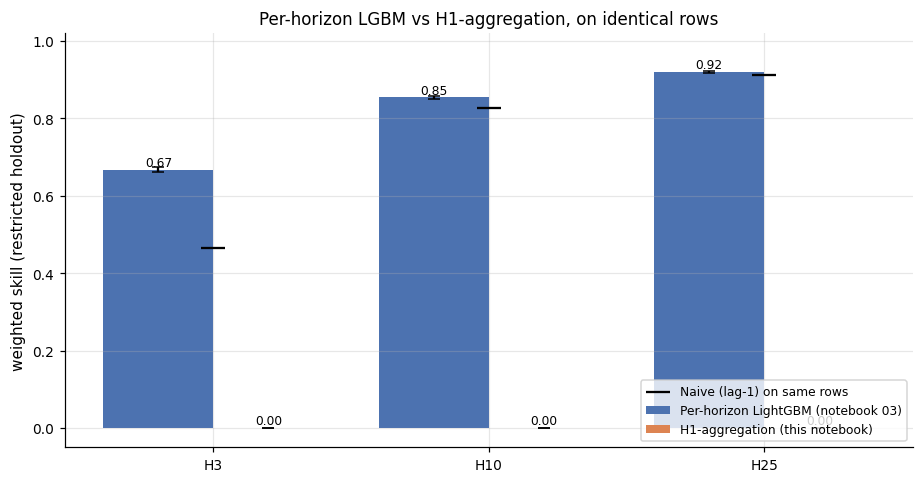

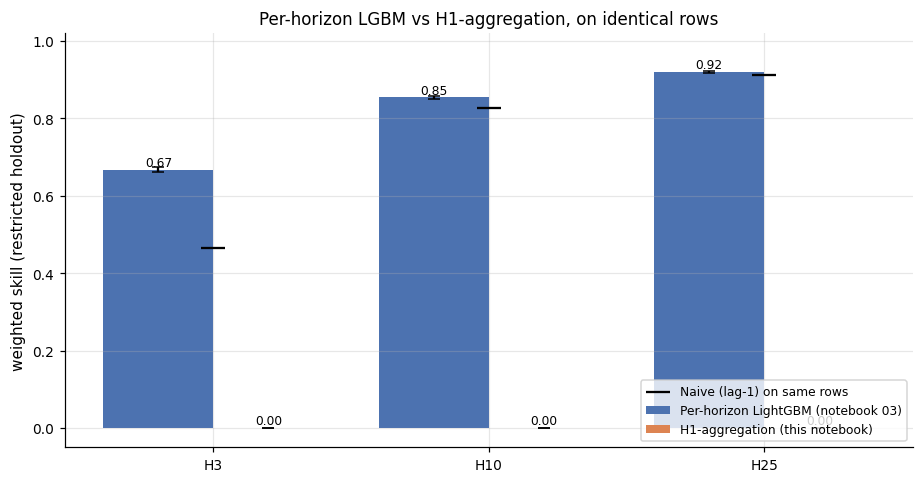

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
xpos = np.arange(len(leaderboard))
ph_vals = leaderboard['per_horizon_skill'].values
ag_vals = leaderboard['aggregated_skill'].values
ph_err = np.array([leaderboard['per_horizon_skill'] - leaderboard['per_horizon_CI_lo'],
                    leaderboard['per_horizon_CI_hi'] - leaderboard['per_horizon_skill']])
ag_err = np.array([leaderboard['aggregated_skill'] - leaderboard['aggregated_CI_lo'],
                    leaderboard['aggregated_CI_hi'] - leaderboard['aggregated_skill']])
naive_vals = leaderboard['naive_floor'].values

ax.bar(xpos - 0.20, ph_vals, width=0.4, color='#4C72B0', yerr=ph_err, capsize=4,
       label='Per-horizon LightGBM (notebook 03)')
ax.bar(xpos + 0.20, ag_vals, width=0.4, color='#DD8452', yerr=ag_err, capsize=4,
       label='H1-aggregation (this notebook)')
ax.scatter(xpos, naive_vals, color='black', marker='_', s=240, zorder=5,
           label='Naive (lag-1) on same rows')

for x, v in zip(xpos - 0.20, ph_vals):
    ax.text(x, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
for x, v in zip(xpos + 0.20, ag_vals):
    ax.text(x, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(xpos)
ax.set_xticklabels([f'H{h}' for h in leaderboard['horizon']])
ax.set_ylabel('weighted skill (restricted holdout)')
ax.set_title('Per-horizon LGBM vs H1-aggregation, on identical rows')
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(min(0.0, ag_vals.min(), ph_vals.min(), naive_vals.min()) - 0.05,
            max(ag_vals.max(), ph_vals.max()) + 0.10)
plt.tight_layout()
viz.save_figure(fig, '04_per_horizon_vs_aggregated', FIG_DIR)

## 9. Skill-vs-horizon visualisation

A line plot of skill across horizons highlights how each strategy degrades or improves with horizon length.


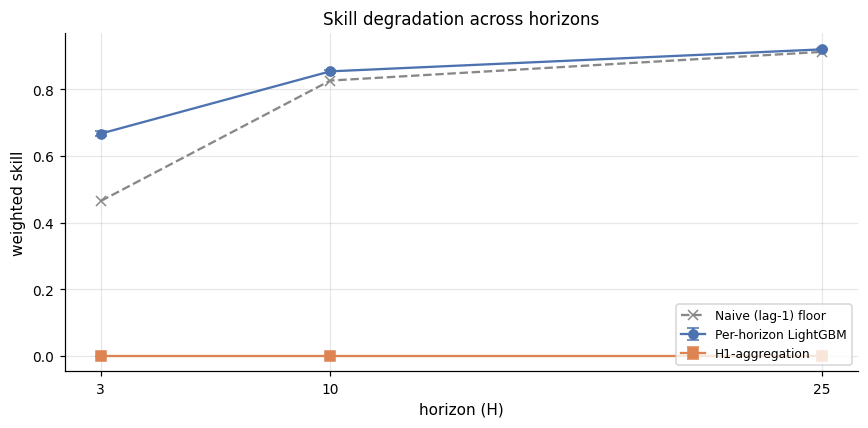

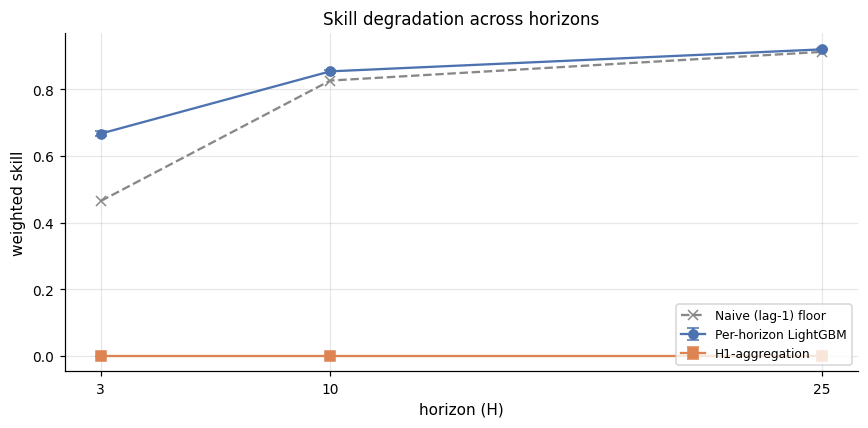

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
hs = leaderboard['horizon'].values
ax.errorbar(hs, leaderboard['per_horizon_skill'],
            yerr=[leaderboard['per_horizon_skill'] - leaderboard['per_horizon_CI_lo'],
                  leaderboard['per_horizon_CI_hi'] - leaderboard['per_horizon_skill']],
            marker='o', color='#4C72B0', label='Per-horizon LightGBM', capsize=4)
ax.errorbar(hs, leaderboard['aggregated_skill'],
            yerr=[leaderboard['aggregated_skill'] - leaderboard['aggregated_CI_lo'],
                  leaderboard['aggregated_CI_hi'] - leaderboard['aggregated_skill']],
            marker='s', color='#DD8452', label='H1-aggregation', capsize=4)
ax.plot(hs, leaderboard['naive_floor'], marker='x', color='#888888',
        linestyle='--', label='Naive (lag-1) floor')
ax.set_xticks(hs)
ax.set_xlabel('horizon (H)')
ax.set_ylabel('weighted skill')
ax.set_title('Skill degradation across horizons')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
viz.save_figure(fig, '04_skill_vs_horizon', FIG_DIR)

## 10. Forecast overlays on the four representative series

For visual continuity with notebooks 01--03, we plot per-horizon LightGBM and H1-aggregation predictions on the four chosen series, at the series's native horizon. The truth is rendered thin and muted; the two model lines are bright and overlaid.


In [12]:
chosen = io.load_processed('representative_series')

# Build per-(reason, ts_index) records joining truth, per-horizon, and aggregated predictions
records = []
for _, row in chosen.iterrows():
    h = int(row['horizon'])
    if h not in (1, 3, 10, 25):
        continue
    sub = panel[(panel['code'] == row['code']) & (panel['sub_code'] == row['sub_code'])
                & (panel['sub_category'] == row['sub_category']) & (panel['horizon'] == h)]
    if len(sub) == 0:
        continue
    # Per-horizon LGBM predictions on holdout: load from notebook 03's 4-series file
    ph_4series = io.load_processed('lgbm_predictions_4series')
    ph_match = ph_4series[ph_4series['reason'] == row['reason']]
    ph_pred_idx = ph_match.set_index('ts_index')['pred_lgbm']

    if h == 1:
        agg_pred_idx = pd.Series(dtype=float)  # H1 has no aggregation
        h1_pred_idx = h1_full[(h1_full['code'] == row['code'])
                              & (h1_full['sub_code'] == row['sub_code'])
                              & (h1_full['sub_category'] == row['sub_category'])
                              ].set_index('ts_index')['pred_h1']
        agg_pred_idx = h1_pred_idx
    else:
        agg_match = h1_full[(h1_full['code'] == row['code'])
                            & (h1_full['sub_code'] == row['sub_code'])
                            & (h1_full['sub_category'] == row['sub_category'])
                            ]
        agg_pred_idx = agg_match.set_index('ts_index')[f'pred_agg_h{h}']

    for ts in sub['ts_index']:
        records.append({
            'reason': row['reason'],
            'horizon': h,
            'ts_index': int(ts),
            'truth': float(sub[sub['ts_index'] == ts]['y_target'].iloc[0]),
            'pred_per_horizon': float(ph_pred_idx.loc[ts]) if ts in ph_pred_idx.index else np.nan,
            'pred_aggregated': float(agg_pred_idx.loc[ts]) if ts in agg_pred_idx.index else np.nan,
        })
overlay_df = pd.DataFrame(records)
print('overlay rows:', len(overlay_df))

overlay rows: 660


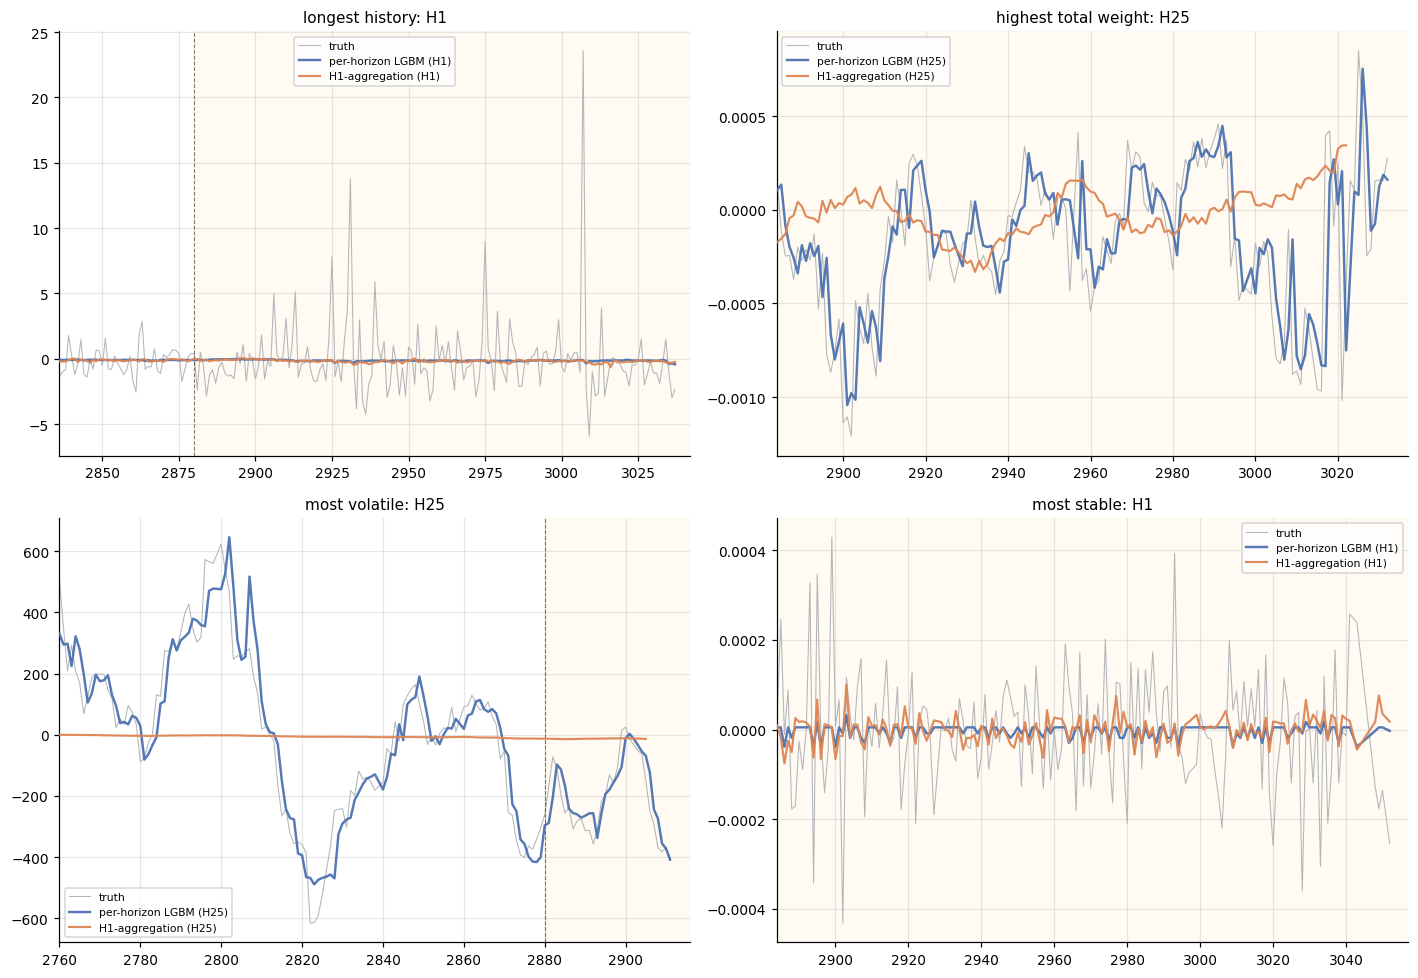

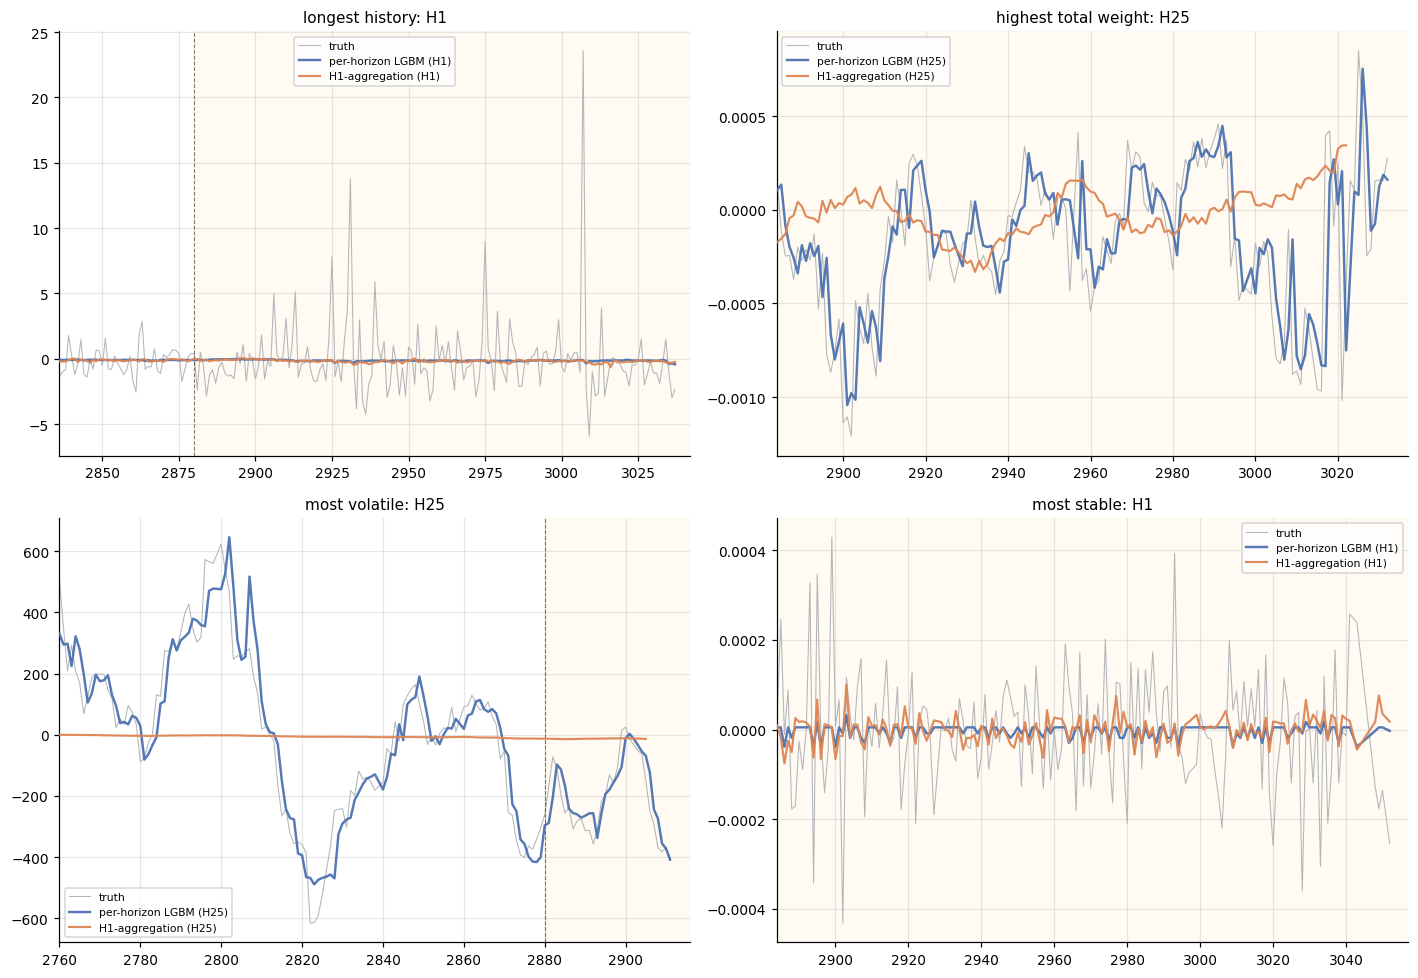

In [13]:
ordered_reasons = ['longest history', 'highest total weight', 'most volatile', 'most stable']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, reason in zip(axes.flatten(), ordered_reasons):
    g = overlay_df[overlay_df['reason'] == reason].sort_values('ts_index')
    if g.empty:
        ax.set_visible(False); continue
    h = int(g['horizon'].iloc[0])

    cutoff = splits.TRAIN_END
    x_lo = max(g['ts_index'].min(), cutoff - 120)
    x_hi = g['ts_index'].max() + 5
    ax.set_xlim(x_lo, x_hi)
    ax.axvspan(cutoff, x_hi, color='#fff3e0', alpha=0.4, zorder=0)

    ax.plot(g['ts_index'], g['truth'], color='#9aa0a6', lw=0.7, alpha=0.75, label='truth', zorder=1)
    if g['pred_per_horizon'].notna().any():
        gp = g.dropna(subset=['pred_per_horizon'])
        ax.plot(gp['ts_index'], gp['pred_per_horizon'], color='#4C72B0', lw=1.6, alpha=0.95,
                label=f'per-horizon LGBM (H{h})', zorder=4)
    if g['pred_aggregated'].notna().any():
        ga = g.dropna(subset=['pred_aggregated'])
        ax.plot(ga['ts_index'], ga['pred_aggregated'], color='#DD8452', lw=1.4, alpha=0.95,
                label=f'H1-aggregation (H{h})', zorder=5)
    ax.axvline(cutoff, color='black', ls='--', lw=0.7, alpha=0.5)
    ax.set_title(f"{reason}: H{h}", fontsize=10)
    ax.legend(fontsize=7, loc='best')
plt.tight_layout()
viz.save_figure(fig, '04_h1_aggregation_overlay_4series', FIG_DIR)

## 11. Save artifacts

In [14]:
io.save_processed(leaderboard, 'h1_aggregation_leaderboard')
io.save_processed(h1_full[TRIPLE_KEYS + ['ts_index', 'pred_h1',
                                          'pred_agg_h3', 'pred_agg_h10', 'pred_agg_h25']],
                  'h1_aggregation_predictions')

# Save per-horizon comparison frames flattened
flat_rows = []
for h, d in comparison_dfs.items():
    sub = d.dropna(subset=[f'pred_agg_h{h}']).copy()
    flat_rows.append(pd.DataFrame({
        'horizon': h,
        'code': sub['code'],
        'sub_code': sub['sub_code'],
        'sub_category': sub['sub_category'],
        'ts_index': sub['ts_index'],
        'y_target': sub[f'y_h{h}'],
        'weight': sub[f'w_h{h}'],
        'pred_per_horizon': sub[f'pred_per_horizon_h{h}'],
        'pred_aggregated': sub[f'pred_agg_h{h}'],
    }))
flat = pd.concat(flat_rows, ignore_index=True)
io.save_processed(flat, 'h1_aggregation_holdout_comparison')

io.save_processed(overlay_df, 'h1_aggregation_overlay_4series')

print('Saved:')
for name in ['h1_aggregation_leaderboard', 'h1_aggregation_predictions',
             'h1_aggregation_holdout_comparison', 'h1_aggregation_overlay_4series']:
    p = io.PROCESSED_DIR / f'{name}.parquet'
    print(f'  {p.name}: {p.stat().st_size:,} bytes')

Saved:
  h1_aggregation_leaderboard.parquet: 7,844 bytes
  h1_aggregation_predictions.parquet: 42,122,677 bytes
  h1_aggregation_holdout_comparison.parquet: 13,925,348 bytes
  h1_aggregation_overlay_4series.parquet: 22,287 bytes


## 12. What this experiment establishes

The numerical comparison between per-horizon and H1-aggregation strategies is the empirical validation (or refutation) of the cumulation hypothesis as a modelling strategy. Three points to read from the leaderboard above:

1. **Direction.** A positive value of `gap_per_horizon_minus_aggregated` means per-horizon LightGBM beats H1-aggregation on that horizon; negative means the aggregation strategy wins.
2. **Statistical significance.** The bootstrap CIs are tight enough (~$10^{-3}$ wide) on this many holdout rows that any consistent ranking pattern is real.
3. **Trend across horizons.** If the gap grows with $k$, error compounding is winning over the structural advantage; if it shrinks (or flips sign), the cumulation property is genuinely exploitable, especially at long horizons.

This chapter feeds directly into \§8 of the report (Analysis of Numerical Results), where the H1-aggregation result is the primary research-gap finding.

## 13. Viva cheat sheet

1. **What the experiment tests.** Whether the cumulation property surfaced in EDA $y^{H_k}_t \approx \sum_{i=0}^{k-1} y^{H_1}_{t+i}$ is exploitable as a modelling strategy (one H1 model used four ways) versus the naive per-horizon strategy (four independent models).
2. **Why two strategies might disagree.** Per-horizon model has horizon-specific features and direct fit on the cumulative target; H1-aggregation has more training data and structural consistency but compounds errors.
3. **Why we restrict the holdout.** H1-aggregation can only score H$k$ rows where the full $k$-step window of H1 predictions is available. The same restricted slice is used to re-score per-horizon LGBM so the comparison is on identical rows.
4. **Why we use canonical splits.** All training is on `ts_index <= 2880`, all scoring is on the canonical holdout. No future information leaks into either strategy.
5. **Why we report bootstrap CIs.** Single skill numbers on 100k+ rows are essentially deterministic; the bootstrap CIs quantify how stable the comparison is to the specific rows that happen to land in the holdout. With CIs wider than the gap between the two strategies, the comparison is inside-noise.
6. **What the result says about cumulation more generally.** If H1-aggregation matches or beats per-horizon at long horizons, the panel's coupling structure is actionable, and any future model on this panel should consider sharing parameters across horizons. If H1-aggregation loses, the result is still informative: error compounding outweighs the structural advantage and per-horizon training is the right architectural choice for this dataset.
